In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
from jax_tqdm import scan_tqdm
import jax
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax.flatten_util import ravel_pytree
from jax import Array
import equinox as eqx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller

from optax import sgd, adam
from dorito.stats import disco_regularised_loss_fn

from zodiax.diffops import hessian, hessian_to_pytree
from kneed import KneeLocator

import dLux.utils as dlu
import blackjax
from blackjax.adaptation.step_size import (
    DualAveragingAdaptationState, dual_averaging_adaptation
)

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)

In [2]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [ ]:
disco_PDS70.keys()

In [3]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


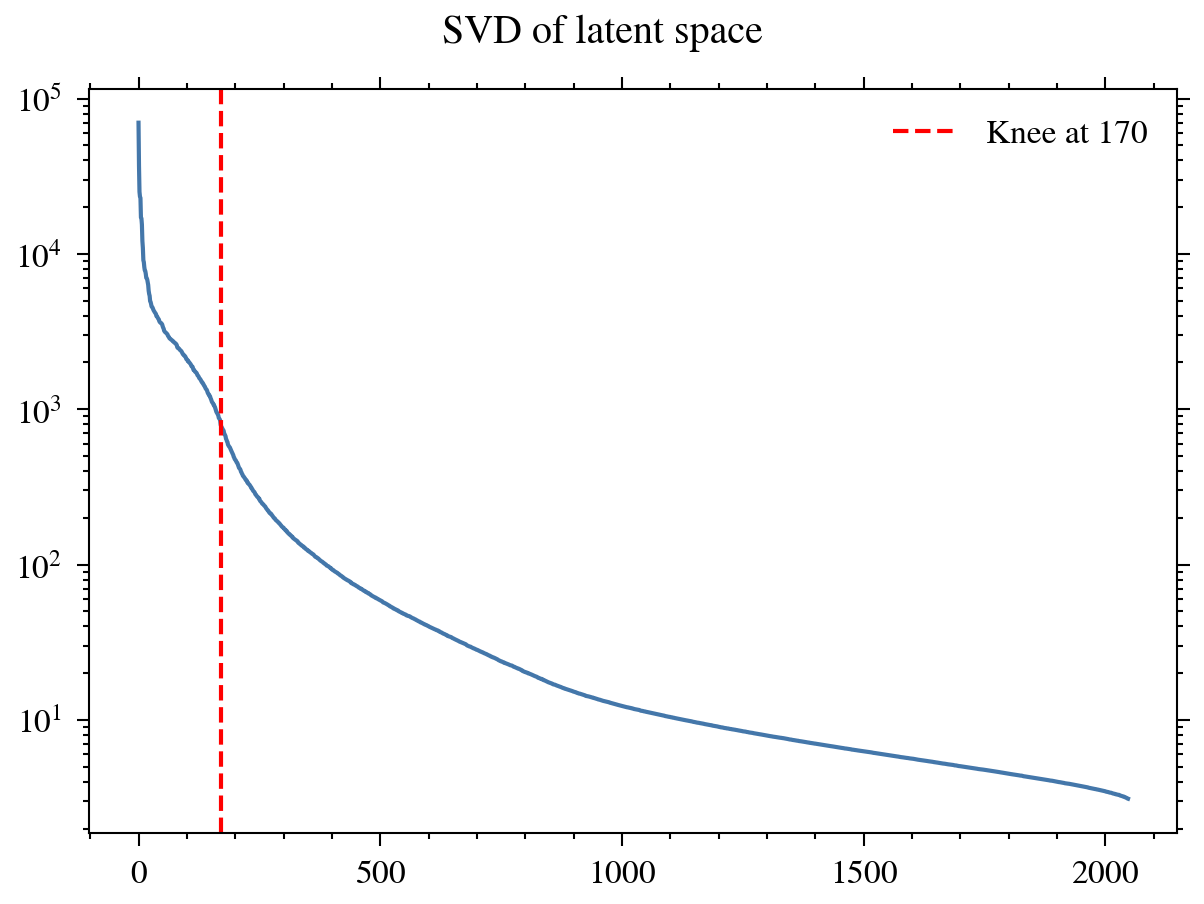

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [4]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [5]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

def sum2unity(X):
    return X / np.sum(X, axis=(1, 2), keepdims=True)

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


Text(0.5, 1.0, 'Initial Distribution | Sum: 1.000000238418579')

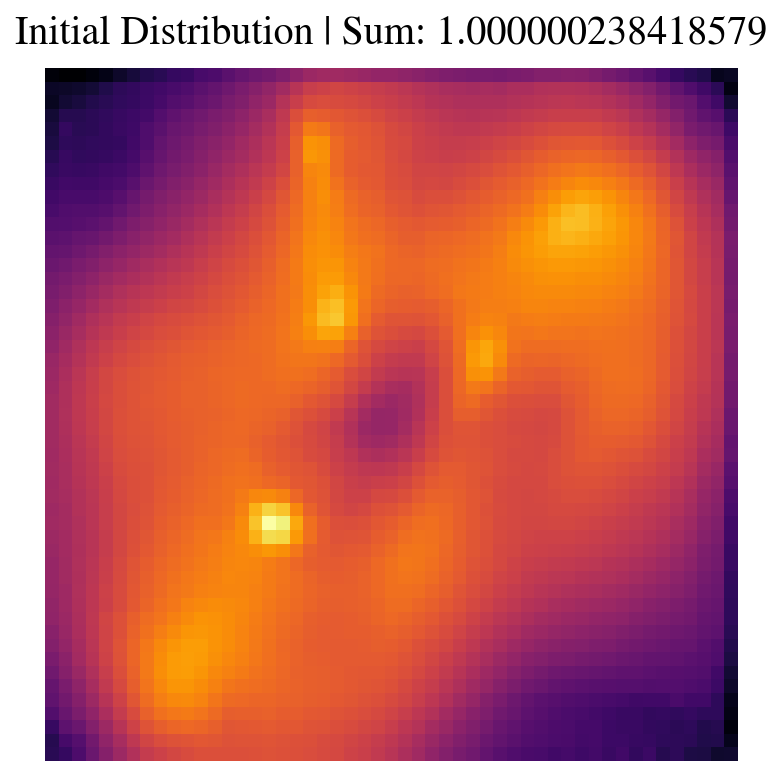

In [6]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [7]:
optics_diameter = 6.603464
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)
basis = AutoencoderBasis(sutured_ae)
ois = [
    PROIF(
        oi_data,
        key,
        filter=key,
    )
    for key, oi_data in disco_PDS70.items()
]
# oi = ois['F3']

In [8]:
model = PRDM(
    ois=ois,
    distribution=init_dist,
    basis=basis,
    contrast=0.045,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)

In [9]:


# ---------------------------------------------------------------
# 1. Define neg log posterior as a function of (log_dist, contrast)
# ---------------------------------------------------------------
# `model` here is your trained MAP model (from `result`)
config = {
    # "log_dist": adam(1e-3, 0),
    "log_dist": adam(5e-5, 0),
    "contrast": sgd(1e-10, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        # "TV": (1e0, drt.stats.TV),
    },
    "basis": basis,
}
x_map = {
    "log_dist": model.params["log_dist"],
    "contrast": model.params["contrast"],
}

def neg_log_post(x):
    new_params = dict(model.params)
    new_params["log_dist"] = x["log_dist"]
    new_params["contrast"] = x["contrast"]
    m = eqx.tree_at(lambda mm: mm.params, model, new_params)

    total = 0.0
    for oi in ois:
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        total = total + loss
    return total

# Quick sanity check: gradient at MAP should be ~0
g = jax.grad(neg_log_post)(x_map)
g_flat, _ = ravel_pytree(g)
print("‖grad‖_inf at MAP:", float(np.max(np.abs(g_flat))))
# If this is large (say > 1e-2 relative to the loss), train longer before proceeding.

# ---------------------------------------------------------------
# 2. Compute Hessian at the MAP and build the inverse mass matrix
# ---------------------------------------------------------------
H, unflatten_h = hessian(neg_log_post, x_map, nbatches=1, jit=True)

# Symmetrise (numerical noise) and regularise to PSD
H_sym = 0.5 * (H + H.T)
eigvals, eigvecs = np.linalg.eigh(H_sym)

# Floor tiny / negative eigenvalues. Pick a floor based on your scale;
# 1e-6 * max eigenvalue is a reasonable default.
floor = 1e-6 * np.max(eigvals)
eigvals_clipped = np.clip(eigvals, floor, None)

# inv mass matrix ≈ posterior covariance ≈ H^{-1}
inv_mass_matrix = (eigvecs * (1.0 / eigvals_clipped)) @ eigvecs.T
inv_mass_matrix = 0.5 * (inv_mass_matrix + inv_mass_matrix.T)  # re-symmetrise

print("condition number of H (clipped):",
      float(eigvals_clipped.max() / eigvals_clipped.min()))


‖grad‖_inf at MAP: 51414.734375
condition number of H (clipped): 1000000.0


In [10]:
# ---------------------------------------------------------------
# 3. Build a flat logdensity for BlackJAX
# ---------------------------------------------------------------
x_flat_map, unflatten = ravel_pytree(x_map)

@jax.jit
def logdensity_fn(z):
    return -neg_log_post(unflatten(z))

In [ ]:
def find_step_size(init_pos, n_steps=500, target_accept=0.8, key=jr.key(0)):
    da_init, da_update, da_final = dual_averaging_adaptation(target=target_accept)
    print('Finding step size with dual averaging warmup...')
    @scan_tqdm(n_steps, desc='Warmup Nuts')
    def one_step(carry, scan_input):
        i, step_key = scan_input
        state, da_state, step_size = carry
        nuts = blackjax.nuts(logdensity_fn, step_size, inv_mass_matrix)
        state, info = nuts.step(step_key, state)
        da_state = da_update(da_state, info.acceptance_rate)
        new_step_size = np.exp(da_state.log_step_size)
        return (state, da_state, new_step_size), None
    
    nuts0 = blackjax.nuts(logdensity_fn, 1e-3, inv_mass_matrix)
    print('nuts0')
    state = nuts0.init(init_pos)
    da_state = da_init(1e-3)
    keys = jr.split(key, n_steps)
    xs = (np.arange(n_steps), keys)    # scan_tqdm needs the index as first elem
    (state, da_state, _), _ = jax.lax.scan(one_step, (state, da_state, 1e-3), xs)
    return float(np.exp(da_final(da_state))), state
step_size, warm_state = find_step_size( x_flat_map, n_steps=500)


Finding step size with dual averaging warmup...
nuts0


Warmup Nuts:   0%|          | 0/500 [00:00<?, ?it/s]